# Inference between model and data of different event types

#### imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time
import math

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko


In [47]:
DATASET_PATH = Path("../../datasets/disasters_merged_all_feats.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
EVENT_GROUPS = ['Avalanche', 'Drought', 'Flood', 'Freeze', 'Heat', 'Heavy Rain', 'Storm', 'Wildfire', 'Wind',]
BATCH_SIZE = 512
TARGET_COLS = ["DAMAGES", "CASUALTIES"]
X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE',
]
df = pd.read_csv(DATASET_PATH)

In [49]:
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze()
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    return avg_diff_damages, avg_diff_casualties

## Cross inference

In [50]:
cross_results = {}

for i, event_group in enumerate(EVENT_GROUPS):
    cross_results[event_group] = {}
    RUN_PATH = Path(f"../../runs/best_flow_{event_group.lower().replace(' ', '_')}.pt")

    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256, 256],
        bins=16,
    )
    flow = flow.to(device)
    flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
    flow.eval()

    for j, target_group in enumerate(EVENT_GROUPS):
        print(f"Evaluating {event_group} model on {target_group} data...")
        target_df = df[df['EVENT_GROUP'] == target_group]
        X = target_df[X_COLS].values.astype(np.float32)
        Y = target_df[TARGET_COLS].values.astype(np.float32)
        Y = np.log1p(Y)
        X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
        X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_train = x_scaler.fit_transform(X_train)
        X_test  = x_scaler.transform(X_test)
        Y_train = y_scaler.fit_transform(Y_train)
        Y_test  = y_scaler.transform(Y_test)
        X_test = torch.tensor(X_test).to(device)
        Y_test = torch.tensor(Y_test).to(device)
        test_ds   = TensorDataset(X_test, Y_test)
        test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

        # compute nll on the test set
        nll = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                dist = flow(x_batch)
                nll += -dist.log_prob(y_batch).sum().item()
        nll /= len(test_loader.dataset)

        avg_diff_damages, avg_diff_casualties = compute_avg_true_pred_diff(flow, test_loader, y_scaler)
        cross_results[event_group][target_group] = {
            "avg_diff_damages": avg_diff_damages,
            "avg_diff_casualties": avg_diff_casualties,
            "nll": nll
        }
        print(f"Avg Diff Damages: {avg_diff_damages:.2f}, Avg Diff Casualties: {avg_diff_casualties:.2f}, NLL: {nll:.2f}")

Evaluating Avalanche model on Avalanche data...
Avg Diff Damages: 8098.96, Avg Diff Casualties: 1.04, NLL: -4.25
Evaluating Avalanche model on Drought data...
Avg Diff Damages: 63894.61, Avg Diff Casualties: 0.04, NLL: 2.65
Evaluating Avalanche model on Flood data...
Avg Diff Damages: 8019156.00, Avg Diff Casualties: 0.11, NLL: 9.57
Evaluating Avalanche model on Freeze data...
Avg Diff Damages: 79512.98, Avg Diff Casualties: 0.18, NLL: 6.91
Evaluating Avalanche model on Heat data...
Avg Diff Damages: 466.94, Avg Diff Casualties: 0.62, NLL: 8.18
Evaluating Avalanche model on Heavy Rain data...
Avg Diff Damages: 14789.64, Avg Diff Casualties: 0.07, NLL: 5.93
Evaluating Avalanche model on Storm data...
Avg Diff Damages: 2216328.25, Avg Diff Casualties: 0.25, NLL: 9.08
Evaluating Avalanche model on Wildfire data...
Avg Diff Damages: 6698358.50, Avg Diff Casualties: 0.68, NLL: 9.00
Evaluating Avalanche model on Wind data...
Avg Diff Damages: 1102308.25, Avg Diff Casualties: 0.08, NLL: 9.64


## Plots

In [51]:
# plot the results as a heatmap
avg_diff_damages_matrix = np.zeros((len(EVENT_GROUPS), len(EVENT_GROUPS)))
avg_diff_casualties_matrix = np.zeros((len(EVENT_GROUPS), len(EVENT_GROUPS)))
nll_matrix = np.zeros((len(EVENT_GROUPS), len(EVENT_GROUPS)))
for i, event_group in enumerate(EVENT_GROUPS):
    for j, target_group in enumerate(EVENT_GROUPS):
        avg_diff_damages_matrix[i, j] = cross_results[event_group][target_group]["avg_diff_damages"]
        avg_diff_casualties_matrix[i, j] = cross_results[event_group][target_group]["avg_diff_casualties"]
        nll_matrix[i, j] = cross_results[event_group][target_group]["nll"]

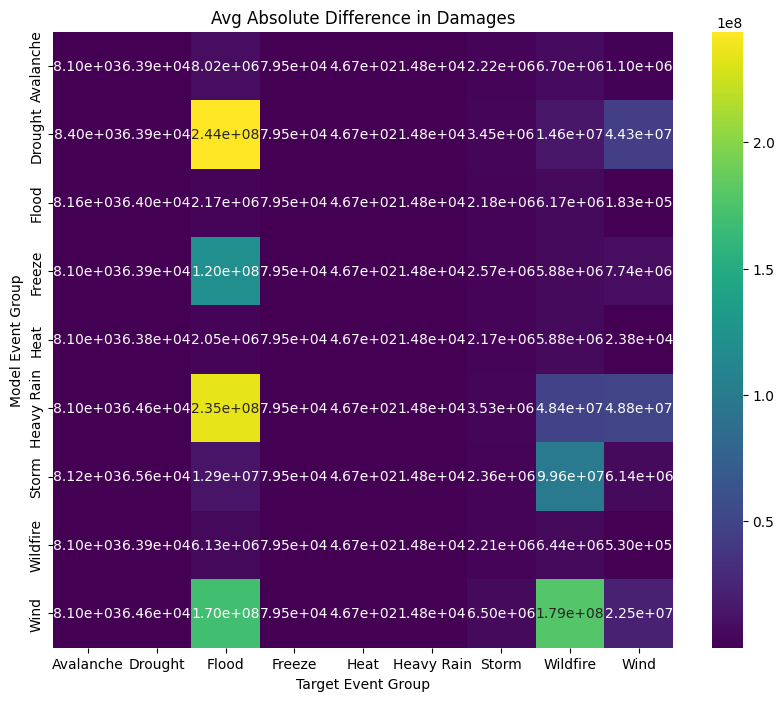

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_diff_damages_matrix, xticklabels=EVENT_GROUPS, yticklabels=EVENT_GROUPS, annot=True, fmt=".2e", cmap="viridis")
plt.title("Avg Absolute Difference in Damages")
plt.xlabel("Target Event Group")
plt.ylabel("Model Event Group")
plt.show()

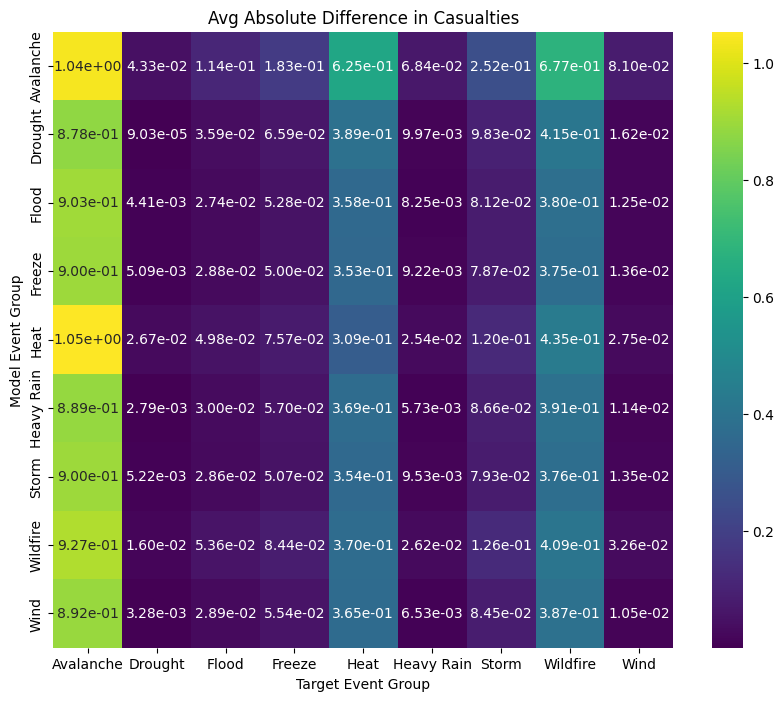

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_diff_casualties_matrix, xticklabels=EVENT_GROUPS, yticklabels=EVENT_GROUPS, annot=True, fmt=".2e", cmap="viridis")
plt.title("Avg Absolute Difference in Casualties")
plt.xlabel("Target Event Group")
plt.ylabel("Model Event Group")
plt.show()

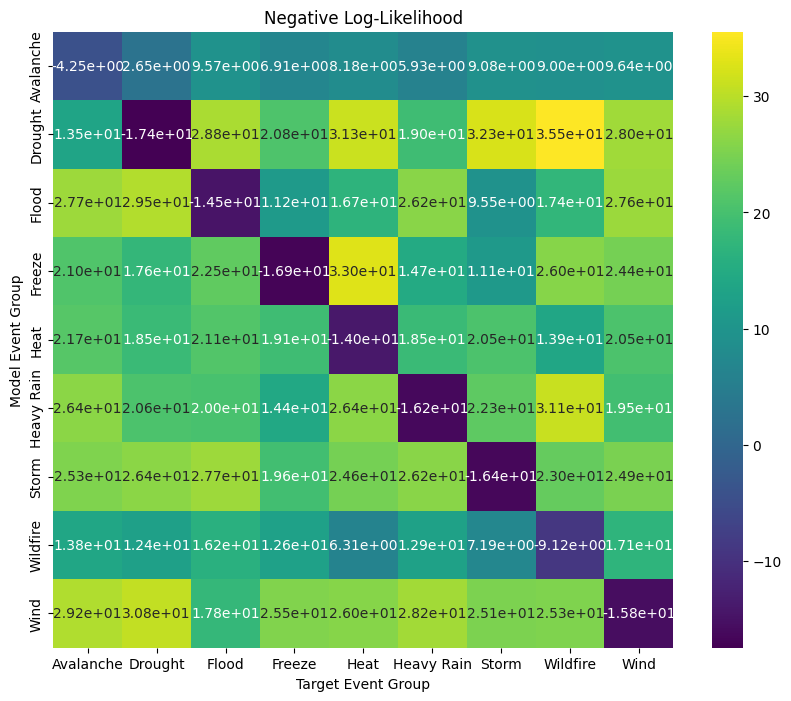

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(nll_matrix, xticklabels=EVENT_GROUPS, yticklabels=EVENT_GROUPS, annot=True, fmt=".2e", cmap="viridis")
plt.title("Negative Log-Likelihood")
plt.xlabel("Target Event Group")
plt.ylabel("Model Event Group")
plt.show()